# Lead Scoring Model

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay,classification_report, roc_auc_score, RocCurveDisplay

%matplotlib inline

In [66]:
df = pd.read_csv("../data/segmented/Segmented_Leads.csv")
df = df.set_index("Lead Number")
df.head(5)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,...,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Cluster
Lead Number,,,,,,,,,,,,,,,,,,,,,
660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Unknown,...,No,No,No,No,Interested in other courses,No,No,No,No,Passive Chat Inquiries
660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,...,No,No,No,No,Ringing,No,No,No,No,Normal Traffic
660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,...,No,No,No,No,Will revert after reading the email,No,No,No,Yes,Normal Traffic
660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Other,India,...,No,No,No,No,Ringing,No,No,No,No,Normal Traffic
660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,...,No,No,No,No,Will revert after reading the email,No,No,No,No,Normal Traffic


In [67]:
y = df["Converted"]
X_val = df.drop(columns="Converted")

In [68]:
X_encoded = pd.get_dummies(data=X_val,drop_first=True)
X_encoded.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,...,Tags_Interested in other courses,Tags_Other,Tags_Ringing,Tags_Unknown,Tags_Will revert after reading the email,A free copy of Mastering The Interview_Yes,Cluster_Marketing Niche Professionals,Cluster_Normal Traffic,Cluster_Passive Chat Inquiries,Cluster_Window Shoppers
Lead Number,,,,,,,,,,,,,,,,,,,,,
660737,0.0,0,0.0,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
660728,5.0,674,2.5,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
660727,2.0,1532,2.0,True,False,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
660719,1.0,305,1.0,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
660681,2.0,1428,1.0,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42)

In [70]:
X_encoded.select_dtypes(include=["number","int"]).nunique()

TotalVisits                      41
Total Time Spent on Website    1731
Page Views Per Visit            114
dtype: int64

In [71]:
X_encoded.select_dtypes("float").columns

Index(['TotalVisits', 'Page Views Per Visit'], dtype='str')

In [72]:
cont_cols = X_encoded.select_dtypes("number").columns # chose "number" type as preciously we saw all the columns we want are already number type
scalar = StandardScaler()
X_train[cont_cols] = scalar.fit_transform(X_train[cont_cols])
X_test[cont_cols] = scalar.transform(X_test[cont_cols])

In [73]:
lr = LogisticRegression(random_state=42,max_iter=1000).fit(X_train,y_train)
predict = lr.predict(X_test)

In [78]:
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1107
           1       0.91      0.87      0.89       741

    accuracy                           0.91      1848
   macro avg       0.91      0.90      0.91      1848
weighted avg       0.91      0.91      0.91      1848



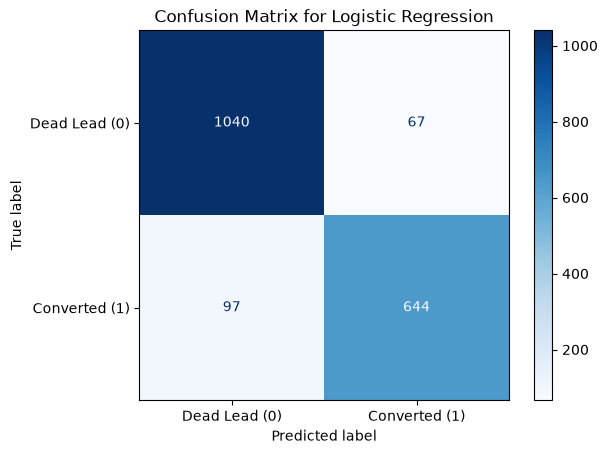

In [84]:
ConfusionMatrixDisplay.from_predictions(y_test,predict,cmap="Blues",display_labels=["Dead Lead (0)","Converted (1)"])
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

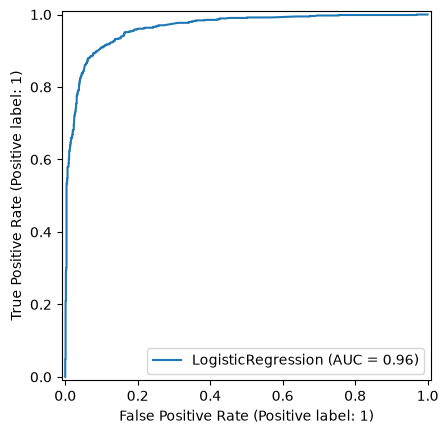

In [93]:
converted_prob = lr.predict_proba(X_test)[:,1]
roc_auc_score(y_test,converted_prob)
RocCurveDisplay.from_estimator(lr,X_test,y_test)